###Import Library yang Digunakan

In [1]:
import os
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image
import cv2
import random
import hashlib
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.layers import Rescaling
from tensorflow.keras import layers, models


###Data Wrangling

###Gathering Data

In [2]:
#Load Dataset
from google.colab import drive
drive.mount('/content/drive')

dataset_path = "/content/drive/MyDrive/Colab Notebooks/Dataset/Dataset_Campur"

dataset = image_dataset_from_directory(
    dataset_path,
    image_size=(224, 224),
    batch_size=32
)

class_names = dataset.class_names

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 9241 files belonging to 3 classes.


In [3]:
#Jumlah Kategori
print("Jumlah Kategori:", len(class_names))

Jumlah Kategori: 3


###Assesing Data

In [4]:
for kategori in os.listdir(dataset_path):
    kategori_path = os.path.join(dataset_path, kategori)

    if os.path.isdir(kategori_path):
        subkategori = [
            d for d in os.listdir(kategori_path)
            if os.path.isdir(os.path.join(kategori_path, d))
        ]

        print(f"\n📁 Kategori: {kategori}")
        print(f"Jumlah Subkategori: {len(subkategori)}")

        for sub in subkategori:
            print(f"   └── {sub}")


📁 Kategori: Organik
Jumlah Subkategori: 3
   └── Tumbuhan
   └── Sisa Buah dan Sayur
   └── Makanan Sisa

📁 Kategori: Anorganik
Jumlah Subkategori: 6
   └── Botol Plastik
   └── Plastik
   └── Metal
   └── Kaca
   └── Kardus dan Kertas
   └── Pakaian

📁 Kategori: B3
Jumlah Subkategori: 1
   └── battery


In [5]:
#Jumlah data per kelas
for kategori in os.listdir(dataset_path):
    kategori_path = os.path.join(dataset_path, kategori)

    if os.path.isdir(kategori_path):

        print(f"\n📁 {kategori}")

        for sub in os.listdir(kategori_path):

            sub_path = os.path.join(kategori_path, sub)

            if os.path.isdir(sub_path):

                files = [
                    f for f in os.listdir(sub_path)
                    if os.path.isfile(os.path.join(sub_path, f))
                ]

                print(f"   └── {sub}: {len(files)} file")


📁 Organik
   └── Tumbuhan: 697 file
   └── Sisa Buah dan Sayur: 857 file
   └── Makanan Sisa: 1059 file

📁 Anorganik
   └── Botol Plastik: 1052 file
   └── Plastik: 747 file
   └── Metal: 864 file
   └── Kaca: 1023 file
   └── Kardus dan Kertas: 1000 file
   └── Pakaian: 902 file

📁 B3
   └── battery: 1040 file


Found 9241 files belonging to 3 classes.


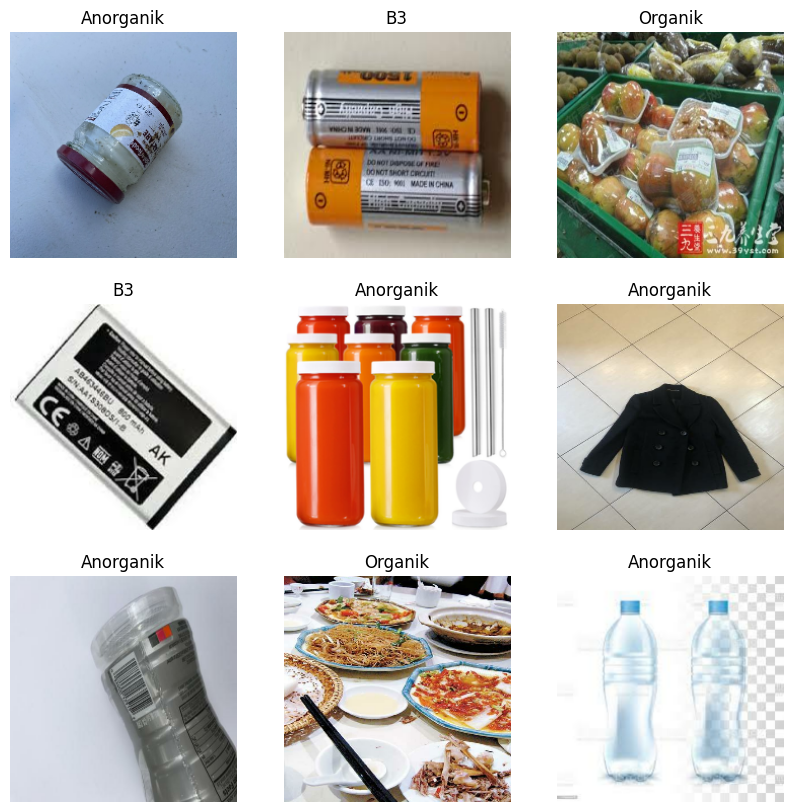

In [6]:
#Visualisasi sample gambar perkategori

dataset_path = "/content/drive/MyDrive/Colab Notebooks/Dataset/Dataset_Campur"

dataset = image_dataset_from_directory(
    dataset_path,
    image_size=(224, 224),
    batch_size=32
)

class_names = dataset.class_names

plt.figure(figsize=(10, 10))

for images, labels in dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [7]:
n_images = 3  # jumlah gambar ke samping

for kategori in os.listdir(dataset_path):
    kategori_path = os.path.join(dataset_path, kategori)

    if os.path.isdir(kategori_path):
        for subkategori in os.listdir(kategori_path):
            sub_path = os.path.join(kategori_path, subkategori)

            if os.path.isdir(sub_path):
                images = [
                    os.path.join(sub_path, f)
                    for f in os.listdir(sub_path)
                    if f.lower().endswith(('.jpg','.jpeg','.png'))
                ]

                if len(images) < n_images:
                    continue

                sample = random.sample(images, n_images)
                plt.figure(figsize=(15, 3))

                for i, img_path in enumerate(sample):
                    img = Image.open(img_path)

                    plt.subplot(1, n_images, i+1)
                    plt.imshow(img)
                    plt.axis("off")

                plt.suptitle(f"{kategori} - {subkategori}", fontsize=12)
                plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [8]:
#Mengecek ukuran gambar
for images, labels in dataset.take(1):
    print("Shape:", images.shape)

Shape: (32, 224, 224, 3)


###Cleaning Data

In [9]:
#Normalisasi pixel
normalization_layer = Rescaling(1./255)
dataset = dataset.map(lambda x, y: (normalization_layer(x), y))

In [10]:
valid_ext = ('.jpg', '.jpeg', '.png')

hash_dict = {}
duplicates = []

def get_image_hash(image_path):

    with Image.open(image_path) as img:
        img = img.convert("RGBA")

        img = img.resize((64, 64))

        img = img.convert("L")

        return hashlib.md5(
            img.tobytes()
        ).hexdigest()

for root, dirs, files in os.walk(dataset_path):

    for file in files:

        if file.lower().endswith(valid_ext):

            file_path = os.path.join(root, file)

            try:

                img_hash = get_image_hash(file_path)

                if img_hash in hash_dict:

                    duplicates.append(
                        (file_path, hash_dict[img_hash])
                    )

                else:

                    hash_dict[img_hash] = file_path

            except Exception as e:

                print("Error:", file_path)

                continue

print(f"Jumlah duplikat ditemukan: {len(duplicates)}")

Jumlah duplikat ditemukan: 622


In [11]:
#Menghapus gambar corrupt
for class_name in class_names:
    class_folder = os.path.join(dataset_path, class_name)

    for root, dirs, files in os.walk(class_folder):
        for file in files:
            file_path = os.path.join(root, file)
            try:
                img = Image.open(file_path)
                img.verify()
            except:
                os.remove(file_path)
                print("Dihapus:", file_path)

###EDA

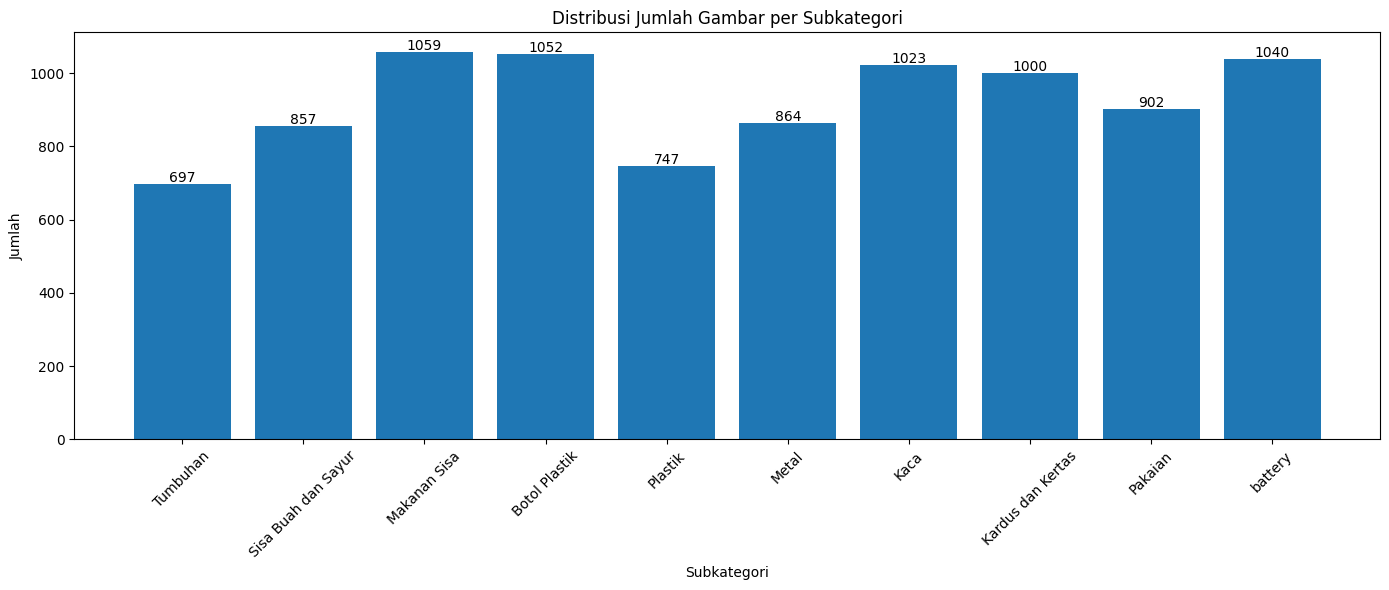

In [12]:
data = []
valid_ext = ('.jpg', '.jpeg', '.png')

for kategori in os.listdir(dataset_path):
    kategori_path = os.path.join(dataset_path, kategori)

    if os.path.isdir(kategori_path):
        for subkategori in os.listdir(kategori_path):
            sub_path = os.path.join(kategori_path, subkategori)

            if os.path.isdir(sub_path):
                total = len([
                    f for f in os.listdir(sub_path)
                    if f.lower().endswith(valid_ext)
                ])

                data.append({
                    "Kategori": kategori,
                    "Kelas": subkategori,
                    "Jumlah": total
                })

df = pd.DataFrame(data)

# Tambah persentase
df["Persentase"] = df["Jumlah"] / df["Jumlah"].sum() * 100

# Visualisasi
plt.figure(figsize=(14,6))
plt.bar(df["Kelas"], df["Jumlah"])

plt.xticks(rotation=45)
plt.title("Distribusi Jumlah Gambar per Subkategori")
plt.xlabel("Subkategori")
plt.ylabel("Jumlah")

for i, v in enumerate(df["Jumlah"]):
    plt.text(i, v + 5, str(v), ha='center')

plt.tight_layout()
plt.show()

Insight
*   Distribusi data menunjukkan ketidakseimbangan antar kelas, di mana kelas anorganik memiliki jumlah data yang lebih banyak dibandingkan kelas lainnya. Hal ini berpotensi menyebabkan model cenderung bias terhadap kelas mayoritas.


/tmp/ipykernel_19158/1046020299.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(edge_per_class.values(), labels=edge_per_class.keys())


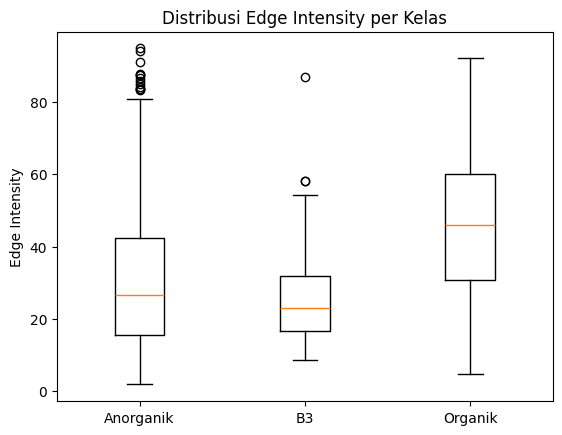

In [13]:
edge_per_class = {}

for class_name in class_names:
    values = []
    class_folder = os.path.join(dataset_path, class_name)

    for root, dirs, files in os.walk(class_folder):
        valid_files = [f for f in files if f.lower().endswith(('.jpg','.jpeg','.png'))]
        sample_files = random.sample(valid_files, min(100, len(valid_files)))

        for file in sample_files:
            try:
                img = cv2.imread(os.path.join(root, file), 0)
                img = cv2.resize(img, (100,100))
                edge = cv2.Canny(img, 100, 200)
                values.append(edge.mean())
            except:
                pass

    edge_per_class[class_name] = values

# Visualisasi
plt.figure()
plt.boxplot(edge_per_class.values(), labels=edge_per_class.keys())
plt.title("Distribusi Edge Intensity per Kelas")
plt.ylabel("Edge Intensity")
plt.show()

Insight
*   Analisis edge intensity menunjukkan bahwa kelas organik memiliki tingkat kompleksitas visual yang jauh lebih tinggi dibandingkan anorganik dan B3, terlihat dari nilai rata-rata edge yang paling besar. Hal ini mengindikasikan bahwa objek organik cenderung memiliki bentuk yang lebih tidak teratur dan tekstur yang lebih kompleks

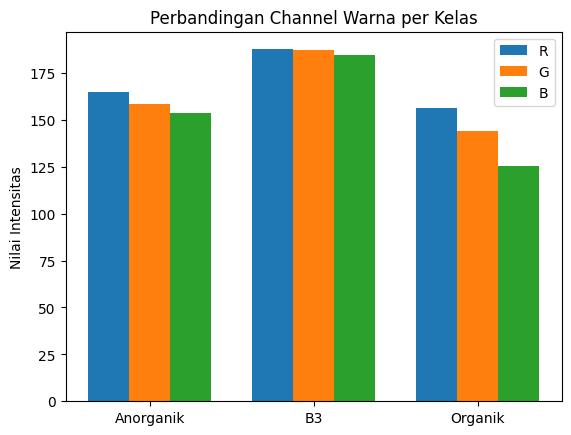

In [14]:
avg_colors = {}

for class_name in class_names:
    pixels = []
    class_folder = os.path.join(dataset_path, class_name)

    for root, dirs, files in os.walk(class_folder):
        valid_files = [f for f in files if f.lower().endswith(('.jpg','.jpeg','.png'))]
        sample_files = random.sample(valid_files, min(100, len(valid_files)))

        for file in sample_files:
            try:
                img_path = os.path.join(root, file)
                img = Image.open(img_path).convert('RGB').resize((50,50))
                arr = np.array(img)

                pixels.append(arr.mean(axis=(0,1)))
            except:
                pass

    avg_colors[class_name] = np.mean(pixels, axis=0)

# Pisahkan channel
labels = list(avg_colors.keys())
r = [avg_colors[k][0] for k in labels]
g = [avg_colors[k][1] for k in labels]
b = [avg_colors[k][2] for k in labels]

# Visualisasi
x = np.arange(len(labels))
width = 0.25

plt.figure()
plt.bar(x - width, r, width, label='R')
plt.bar(x, g, width, label='G')
plt.bar(x + width, b, width, label='B')

plt.xticks(x, labels)
plt.title("Perbandingan Channel Warna per Kelas")
plt.ylabel("Nilai Intensitas")
plt.legend()
plt.show()

Insight
*   Analisis warna menunjukkan bahwa tidak terdapat perbedaan yang sangat kontras antar kelas, karena nilai RGB ketiganya relatif berdekatan. Namun, kelas B3 cenderung lebih terang (nilai RGB lebih tinggi), sedangkan organik memiliki kecenderungan warna lebih gelap dan kehijauan (nilai G dan B lebih rendah).

/tmp/ipykernel_19158/974391004.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(brightness_per_class.values(), labels=brightness_per_class.keys())


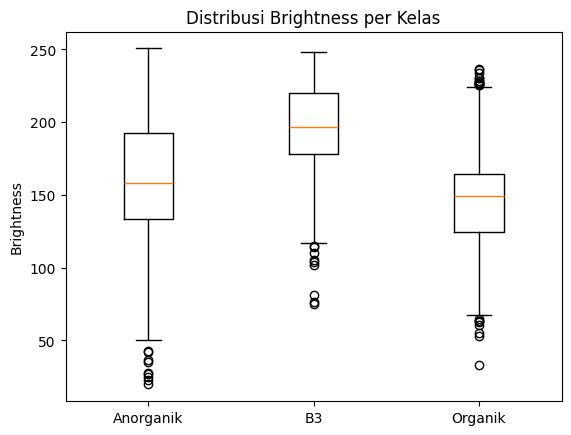

In [15]:
brightness_per_class = {}

for class_name in class_names:
    values = []
    class_folder = os.path.join(dataset_path, class_name)

    for root, dirs, files in os.walk(class_folder):
        valid_files = [f for f in files if f.lower().endswith(('.jpg','.jpeg','.png'))]
        sample_files = random.sample(valid_files, min(150, len(valid_files)))

        for file in sample_files:
            try:
                img = Image.open(os.path.join(root, file)).convert('L')
                values.append(np.mean(img))
            except:
                pass

    brightness_per_class[class_name] = values

# Visualisasi
plt.figure()
plt.boxplot(brightness_per_class.values(), labels=brightness_per_class.keys())
plt.title("Distribusi Brightness per Kelas")
plt.ylabel("Brightness")
plt.show()

Insight
*   Analisis brightness menunjukkan adanya perbedaan kecerahan yang cukup signifikan antar kelas, dengan B3 paling terang dan organik paling gelap. Hal ini mengindikasikan potensi bias pencahayaan dalam dataset, di mana model berisiko belajar dari intensitas cahaya, bukan karakteristik objek

# Visualization & Explanatory Analysis

## Pertanyaan 1: Fitur visual apa yang paling berpotensi digunakan oleh model dalam membedakan jenis sampah: warna atau tekstur?

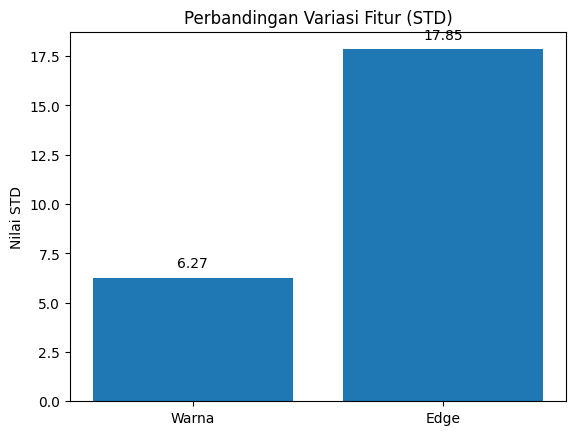

In [16]:
color_std = np.mean([
    np.std(v) for v in avg_colors.values()
])

# STD edge
edge_std = np.mean([
    np.std(v) for v in edge_per_class.values()
])

labels = ['Warna', 'Edge']
values = [color_std, edge_std]

plt.figure()
plt.bar(labels, values)

plt.title("Perbandingan Variasi Fitur (STD)")
plt.ylabel("Nilai STD")

for i, v in enumerate(values):
    plt.text(i, v + 0.5, f"{v:.2f}", ha='center')

plt.show()

Insight
*   Analisis menunjukkan bahwa variasi fitur edge (tekstur/bentuk) jauh lebih tinggi dibandingkan variasi warna pada seluruh kelas. Hal ini mengindikasikan bahwa perbedaan visual antar objek lebih banyak dipengaruhi oleh kompleksitas bentuk dan tekstur dibandingkan warna. Dengan demikian, model kemungkinan besar akan lebih mengandalkan fitur edge dalam membedakan jenis sampah, sementara warna hanya berperan sebagai fitur pendukung yang kontribusinya relatif kecil.

## Pertanyaan 2: Apakah terdapat indikasi bias dalam dataset akibat perbedaan pencahayaan atau kompleksitas visual?

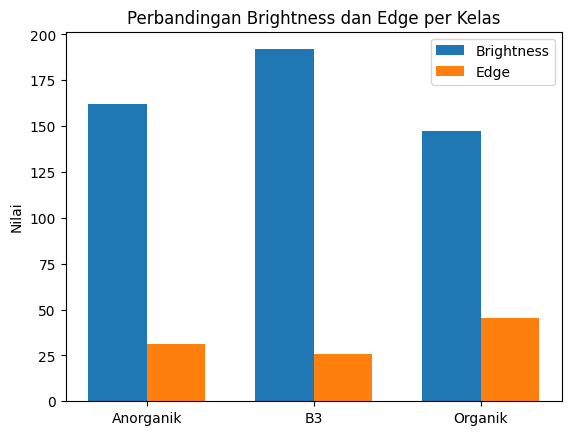

In [17]:
brightness_stats = {}

for class_name, values in brightness_per_class.items():
    brightness_stats[class_name] = {
        "mean": np.mean(values),
        "std": np.std(values)
    }

edge_stats = {}

for class_name, values in edge_per_class.items():
    edge_stats[class_name] = {
        "mean": np.mean(values),
        "std": np.std(values)
    }
# Mean brightness per kategori
brightness_means = [v["mean"] for v in brightness_stats.values()]

# Mean edge per kategori
edge_means = [v["mean"] for v in edge_stats.values()]

labels = list(brightness_stats.keys())

x = np.arange(len(labels))
width = 0.35

plt.figure()

plt.bar(x - width/2, brightness_means, width, label='Brightness')
plt.bar(x + width/2, edge_means, width, label='Edge')

plt.xticks(x, labels)
plt.title("Perbandingan Brightness dan Edge per Kelas")
plt.ylabel("Nilai")
plt.legend()

plt.show()

Insight
*   Analisis menunjukkan adanya indikasi bias pada dataset, terlihat dari gap brightness (30.0) dan edge (18.9) yang cukup besar antar kelas. Kelas B3 cenderung lebih terang, sedangkan organik memiliki kompleksitas visual lebih tinggi. Hal ini mengindikasikan bahwa model berpotensi memanfaatkan pencahayaan dan tekstur sebagai pembeda, bukan hanya karakteristik objek.

###3. Apakah terdapat overlap antar kelas berdasarkan fitur brightness dan edge yang dapat menyulitkan model dalam klasifikasi?

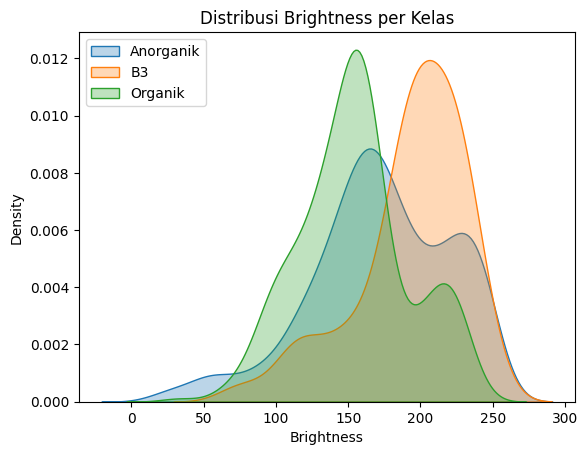

In [18]:
rows = []

for class_name in class_names:
    for b, e in zip(brightness_per_class[class_name], edge_per_class[class_name]):
        rows.append({
            "Kelas": class_name,
            "Brightness": b,
            "Edge": e
        })

df_analysis = pd.DataFrame(rows)
plt.figure()

for kelas in df_analysis["Kelas"].unique():
    subset = df_analysis[df_analysis["Kelas"] == kelas]
    sns.kdeplot(subset["Brightness"], label=kelas, fill=True, alpha=0.3)

plt.title("Distribusi Brightness per Kelas")
plt.xlabel("Brightness")
plt.legend()
plt.show()

Insight
*   Distribusi brightness menunjukkan adanya overlap yang cukup besar antar kelas, terutama antara anorganik dan B3, serta sebagian dengan organik. Hal ini mengindikasikan bahwa brightness saja tidak cukup kuat untuk memisahkan kelas secara jelas, karena banyak nilai yang saling tumpang tindih. Namun, terlihat bahwa organik cenderung berada di area brightness yang lebih rendah, sehingga masih memberikan sedikit pola pembeda

###4. Seberapa konsisten karakteristik visual (brightness dan edge) di dalam masing-masing kelas?

=== CV Brightness ===
Anorganik 0.2796554278385499
B3 0.19503331972087656
Organik 0.25332660473367535

=== CV Edge ===
Anorganik 0.642117296472179
B3 0.4801142813904711
Organik 0.4659489399821742


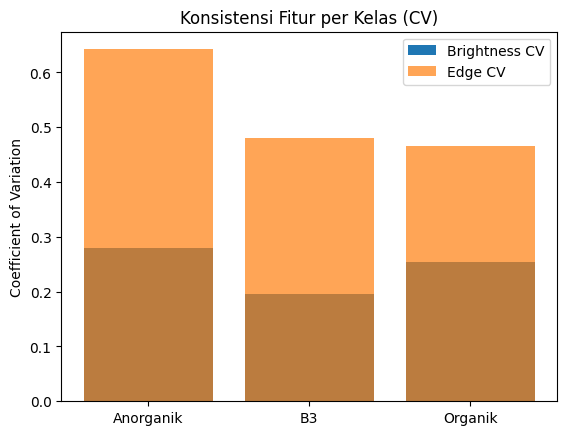

In [19]:
# Hitung coefficient of variation (CV = std/mean)
cv_brightness = {}
cv_edge = {}

for k in brightness_stats:
    cv_brightness[k] = brightness_stats[k]["std"] / brightness_stats[k]["mean"]
    cv_edge[k] = edge_stats[k]["std"] / edge_stats[k]["mean"]

print("=== CV Brightness ===")
for k, v in cv_brightness.items():
    print(k, v)

print("\n=== CV Edge ===")
for k, v in cv_edge.items():
    print(k, v)

#Visualisasi
labels = list(cv_brightness.keys())

plt.figure()
plt.bar(labels, list(cv_brightness.values()), label="Brightness CV")
plt.bar(labels, list(cv_edge.values()), alpha=0.7, label="Edge CV")
plt.title("Konsistensi Fitur per Kelas (CV)")
plt.ylabel("Coefficient of Variation")
plt.legend()
plt.show()

Insight
*   Analisis konsistensi fitur menunjukkan bahwa brightness memiliki tingkat variasi yang lebih rendah dibandingkan edge pada semua kelas, sehingga lebih stabil dalam merepresentasikan karakteristik data. Sebaliknya, edge memiliki variasi yang tinggi, yang menandakan bahwa kompleksitas bentuk dan tekstur dalam satu kelas cukup beragam. Hal ini mengindikasikan bahwa meskipun edge kuat sebagai pembeda antar kelas, sifatnya yang tidak konsisten dapat menyulitkan model dalam menangkap pola yang stabil,

###Data Preparation

In [20]:
#Split Data
train_ds = image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224,224),
    batch_size=32
)

val_ds = image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224,224),
    batch_size=32
)

Found 9241 files belonging to 3 classes.
Using 7393 files for training.
Found 9241 files belonging to 3 classes.
Using 1848 files for validation.


In [21]:
#Normalisasi Pipeline
normalization_layer = Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

In [22]:
#Shuffle dan Prefetch
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

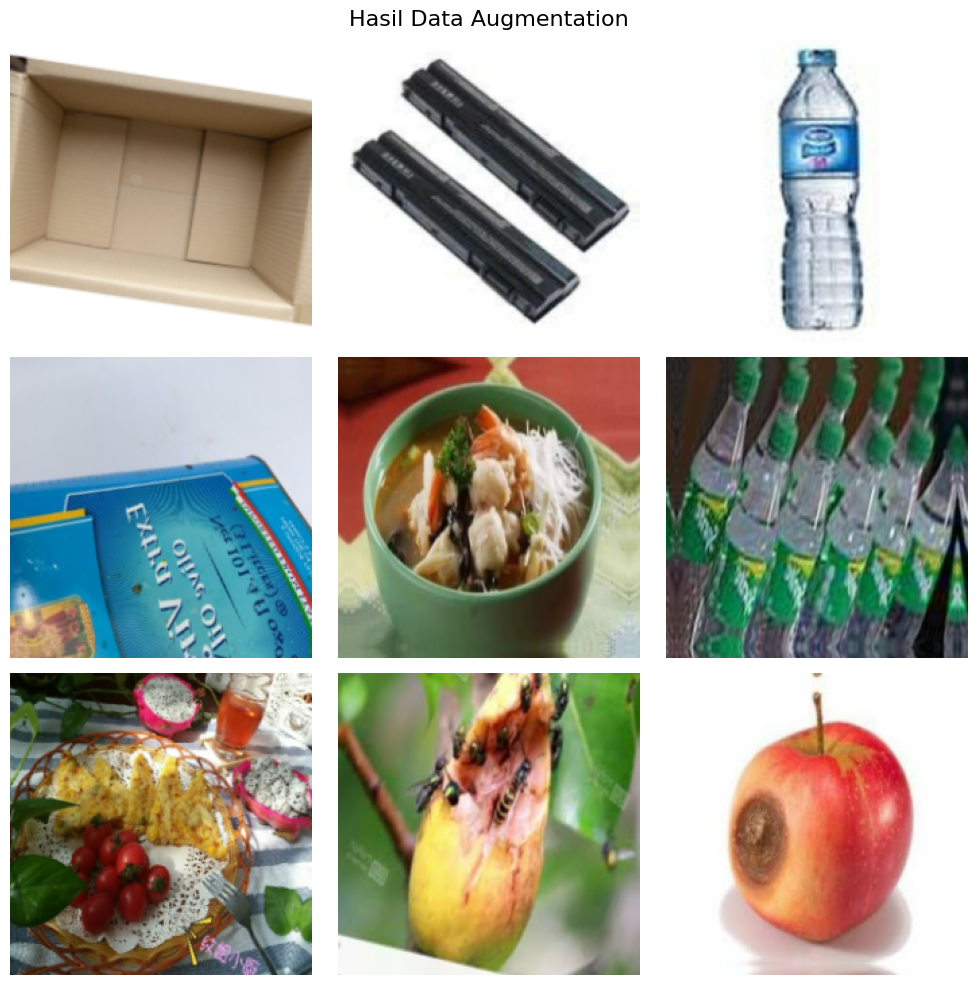

In [23]:
# Data Augmentation
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers

#Augmentasi data
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
])

# Visualisasi hasil augmentasi
for images, labels in train_ds.take(1):

    # Terapkan augmentasi
    augmented_images = data_augmentation(images)

    # Pastikan pixel tetap di range 0–1
    augmented_images = tf.clip_by_value(
        augmented_images,
        0.0,
        1.0
    )

    # Plot gambar
    plt.figure(figsize=(10,10))

    for i in range(9):

        ax = plt.subplot(3,3,i+1)

        plt.imshow(augmented_images[i].numpy())

        plt.axis("off")

    plt.suptitle("Hasil Data Augmentation", fontsize=16)

    plt.tight_layout()

    plt.show()

###Feature Engineering

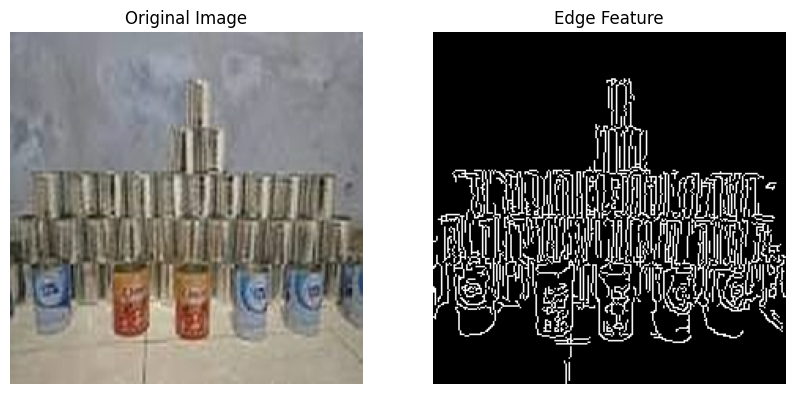

In [24]:
#Edge Extraction
# Ambil 1 batch
for images, labels in train_ds.take(1):

    # Ambil 1 gambar
    image = images[0].numpy()

    # Ubah ke uint8
    image_uint8 = (image * 255).astype(np.uint8)

    # Grayscale
    gray = cv2.cvtColor(image_uint8, cv2.COLOR_RGB2GRAY)

    # Edge Detection
    edges = cv2.Canny(gray, 100, 200)

    # Visualisasi
    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.imshow(image)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(edges, cmap='gray')
    plt.title("Edge Feature")
    plt.axis("off")

    plt.show()

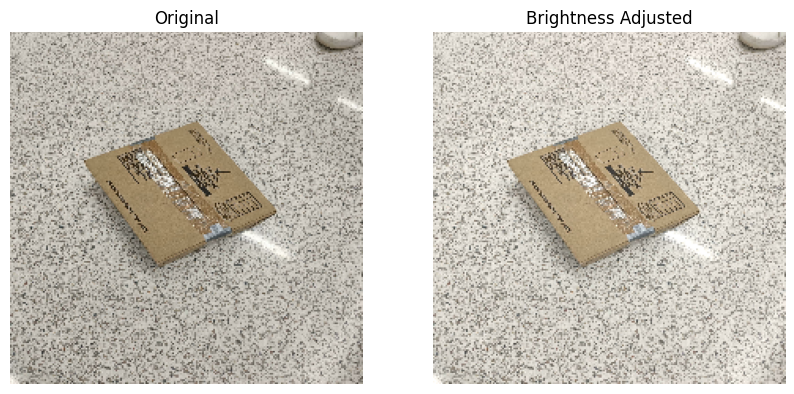

In [25]:
#Brightness Enhancement
for images, labels in train_ds.take(1):

    image = images[0].numpy()

    # Brightness normalization
    bright_image = tf.image.adjust_brightness(
        image,
        delta=0.1
    )

    bright_image = tf.clip_by_value(
        bright_image,
        0.0,
        1.0
    )

    # Visualisasi
    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.imshow(image)
    plt.title("Original")

    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(bright_image)
    plt.title("Brightness Adjusted")

    plt.axis("off")

    plt.show()

###Perbandingan Model ML

In [ ]:
#MODEL A (Tanpa Augmentation)
model_A = models.Sequential([

    layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(224,224,3)
    ),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),

    layers.Dropout(0.5),

    layers.Dense(len(class_names), activation='softmax')
])

model_A.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
#Train
history_A = model_A.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
204/232 ━━━━━━━━━━━━━━━━━━━━ 1:47 4s/step - accuracy: 0.6624 - loss: 0.8924

In [ ]:
#MODEL B (Dengan Augmentation)
model_B = models.Sequential([

    # Augmentation
    data_augmentation,

    layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(224,224,3)
    ),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),

    layers.Dropout(0.5),

    layers.Dense(len(class_names), activation='softmax')
])

model_B.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
#Train
history_B = model_B.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

In [ ]:
#PERBANDINGAN HASIL (A/B TEST)
acc_A = history_A.history['val_accuracy'][-1]
acc_B = history_B.history['val_accuracy'][-1]

print("Validation Accuracy Model A :", acc_A)
print("Validation Accuracy Model B :", acc_B)

In [ ]:
#Visualisasi Perbandingan
labels = ['Tanpa Augmentasi', 'Dengan Augmentasi']
values = [acc_A, acc_B]

plt.figure(figsize=(6,4))

plt.bar(labels, values)

plt.ylabel("Validation Accuracy")

plt.title("Perbandingan Model A/B")

for i, v in enumerate(values):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.show()